# Step 3 — Class Imbalance Handling

compare three approaches:
- **Baseline**: `scale_pos_weight=6` (original guessed value)
- **Fixed Weight**: `scale_pos_weight` set to the true class ratio (~11.6)
- **SMOTE**: oversample the minority class, then train with `scale_pos_weight=1`

In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

print('All imports successful!')

All imports successful!


In [2]:
df = pd.read_csv('../data/american_bankruptcy_dataset.csv')
df['target'] = (df['status_label'] == 'failed').astype(int)

train_df = df[df['fyear'] <= 2011]
val_df   = df[(df['fyear'] >= 2012) & (df['fyear'] <= 2014)]
test_df  = df[df['fyear'] >= 2015]

FEATURES = ['X1','X2','X3','X4','X5','X6','X7','X8',
            'X9','X10','X11','X12','X13','X14','X15',
            'X16','X17','X18','Division']

X_train = train_df[FEATURES]
y_train = train_df['target']
X_val   = val_df[FEATURES]
y_val   = val_df['target']
X_test  = test_df[FEATURES]
y_test  = test_df['target']

alive  = (y_train == 0).sum()
failed = (y_train == 1).sum()
true_ratio = round(alive / failed, 2)

print(f'Train — Alive: {alive}, Failed: {failed}')
print(f'True class ratio (scale_pos_weight): {true_ratio}')

Train — Alive: 51485, Failed: 4442
True class ratio (scale_pos_weight): 11.59


In [3]:
cat_idx = [FEATURES.index('Division')]

val_pool  = Pool(X_val,  y_val,  cat_features=cat_idx)
test_pool = Pool(X_test, y_test, cat_features=cat_idx)

def train_and_evaluate(X_tr, y_tr, scale_weight, label, cat_indices=cat_idx):
    pool_tr = Pool(X_tr, y_tr, cat_features=cat_indices)
    m = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        early_stopping_rounds=50,
        scale_pos_weight=scale_weight,
        verbose=False
    )
    m.fit(pool_tr, eval_set=val_pool)
    proba = m.predict_proba(test_pool)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    print(f'\n=== {label} (scale_pos_weight={scale_weight}) ===')
    print(f'Test AUC: {auc:.4f}')
    print(classification_report(y_test, (proba >= 0.4).astype(int),
                                target_names=['Alive', 'Failed']))
    return m, proba, auc

print('Helper function ready.')

Helper function ready.


## Approach 1 — Baseline (scale_pos_weight = 6)

In [4]:
model_baseline, proba_baseline, auc_baseline = train_and_evaluate(
    X_train, y_train, scale_weight=6, label='Baseline'
)


=== Baseline (scale_pos_weight=6) ===
Test AUC: 0.8241
              precision    recall  f1-score   support

       Alive       0.99      0.77      0.87     11995
      Failed       0.07      0.70      0.13       287

    accuracy                           0.77     12282
   macro avg       0.53      0.74      0.50     12282
weighted avg       0.97      0.77      0.85     12282



## Approach 2 — Fixed Weight (true class ratio)

In [5]:
model_fixed, proba_fixed, auc_fixed = train_and_evaluate(
    X_train, y_train, scale_weight=true_ratio, label='Fixed Weight'
)


=== Fixed Weight (scale_pos_weight=11.59) ===
Test AUC: 0.8248
              precision    recall  f1-score   support

       Alive       1.00      0.49      0.66     11995
      Failed       0.04      0.91      0.08       287

    accuracy                           0.50     12282
   macro avg       0.52      0.70      0.37     12282
weighted avg       0.97      0.50      0.64     12282



## Approach 3 — SMOTE Oversampling

SMOTE cannot handle categorical features directly, so we one-hot encode `Division` before resampling, then pass the resampled data to CatBoost without categorical features.

In [6]:
# One-hot encode Division for SMOTE
X_train_enc = pd.get_dummies(X_train, columns=['Division'])
X_val_enc   = pd.get_dummies(X_val,   columns=['Division'])
X_test_enc  = pd.get_dummies(X_test,  columns=['Division'])

# Align columns in case val/test are missing some Division categories
X_val_enc  = X_val_enc.reindex(columns=X_train_enc.columns,  fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_enc, y_train)

print(f'After SMOTE — Alive: {(y_train_sm==0).sum()}, Failed: {(y_train_sm==1).sum()}')

After SMOTE — Alive: 51485, Failed: 51485


In [7]:
# Train on SMOTE data (no categorical features — already encoded)
val_pool_enc  = Pool(X_val_enc,  y_val)
test_pool_enc = Pool(X_test_enc, y_test)

model_smote = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=50,
    scale_pos_weight=1,
    verbose=False
)
model_smote.fit(Pool(X_train_sm, y_train_sm), eval_set=val_pool_enc)

proba_smote = model_smote.predict_proba(test_pool_enc)[:, 1]
auc_smote   = roc_auc_score(y_test, proba_smote)

print(f'\n=== SMOTE (scale_pos_weight=1) ===')
print(f'Test AUC: {auc_smote:.4f}')
print(classification_report(y_test, (proba_smote >= 0.4).astype(int),
                            target_names=['Alive', 'Failed']))


=== SMOTE (scale_pos_weight=1) ===
Test AUC: 0.7546
              precision    recall  f1-score   support

       Alive       0.99      0.74      0.85     11995
      Failed       0.06      0.66      0.11       287

    accuracy                           0.74     12282
   macro avg       0.52      0.70      0.48     12282
weighted avg       0.97      0.74      0.83     12282



## Comparison Summary

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for label, proba in [('Baseline (weight=6)', proba_baseline),
                      (f'Fixed Weight ({true_ratio})', proba_fixed),
                      ('SMOTE', proba_smote)]:
    preds = (proba >= 0.4).astype(int)
    rows.append({
        'Approach': label,
        'AUC':      round(roc_auc_score(y_test, proba), 4),
        'Failed Recall':    round(recall_score(y_test, preds, pos_label=1), 3),
        'Failed Precision': round(precision_score(y_test, preds, pos_label=1, zero_division=0), 3),
        'Failed F1':        round(f1_score(y_test, preds, pos_label=1, zero_division=0), 3),
    })

summary = pd.DataFrame(rows).set_index('Approach')
print(summary.to_string())

                         AUC  Failed Recall  Failed Precision  Failed F1
Approach                                                                
Baseline (weight=6)   0.8241          0.704             0.069      0.125
Fixed Weight (11.59)  0.8248          0.909             0.041      0.078
SMOTE                 0.7546          0.659             0.058      0.106


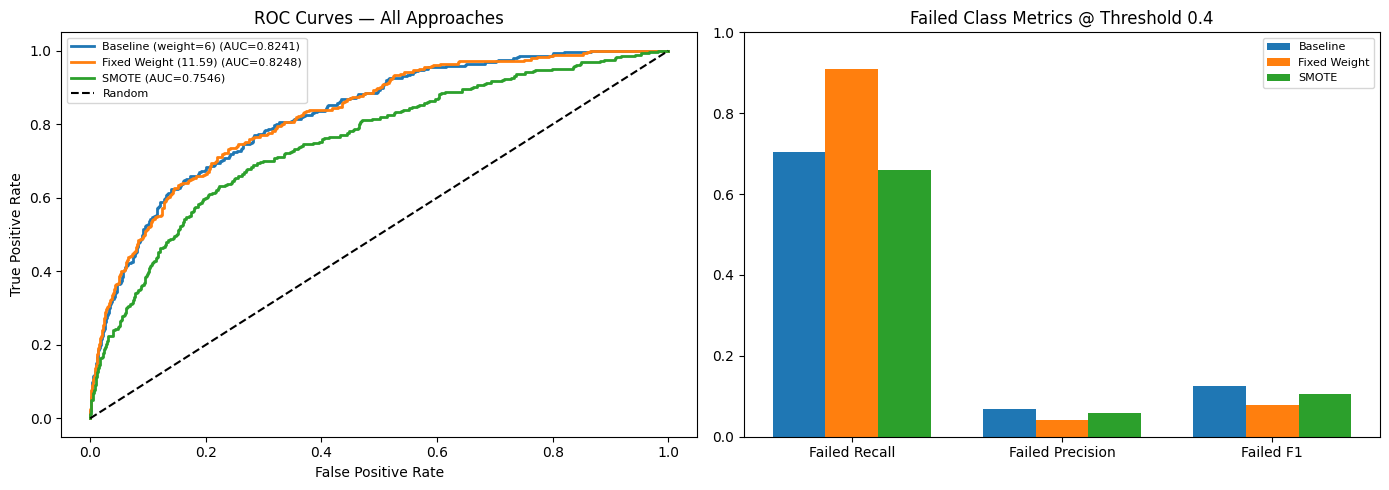

In [9]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
ax = axes[0]
for label, proba in [('Baseline (weight=6)', proba_baseline),
                      (f'Fixed Weight ({true_ratio})', proba_fixed),
                      ('SMOTE', proba_smote)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.4f})')
ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Approaches')
ax.legend(fontsize=8)

# Failed-class metrics bar chart
ax2 = axes[1]
metrics = ['Failed Recall', 'Failed Precision', 'Failed F1']
x = np.arange(len(metrics))
width = 0.25
for i, (label, proba) in enumerate([('Baseline', proba_baseline),
                                      ('Fixed Weight', proba_fixed),
                                      ('SMOTE', proba_smote)]):
    preds = (proba >= 0.4).astype(int)
    vals = [
        recall_score(y_test, preds, pos_label=1),
        precision_score(y_test, preds, pos_label=1, zero_division=0),
        f1_score(y_test, preds, pos_label=1, zero_division=0)
    ]
    ax2.bar(x + i*width, vals, width, label=label)
ax2.set_xticks(x + width)
ax2.set_xticklabels(metrics)
ax2.set_ylim(0, 1)
ax2.set_title('Failed Class Metrics @ Threshold 0.4')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
# Save the best model (determined by Failed F1 score)
import joblib, os

best_label = summary['Failed F1'].idxmax()
print(f'Best approach by Failed F1: {best_label}')

best_model_map = {
    'Baseline (weight=6)':           model_baseline,
    f'Fixed Weight ({true_ratio})':  model_fixed,
    'SMOTE':                          model_smote,
}
best_model = best_model_map[best_label]

os.makedirs('../model', exist_ok=True)
if best_label == 'SMOTE':
    best_model.save_model('../model/catboost_bankruptcy.cbm')
    joblib.dump({'approach': 'SMOTE', 'threshold': 0.4,
                 'features': list(X_train_enc.columns)},
                '../model/app_metadata.joblib')
else:
    best_model.save_model('../model/catboost_bankruptcy.cbm')
    joblib.dump({'approach': best_label, 'threshold': 0.4,
                 'features': FEATURES},
                '../model/app_metadata.joblib')

print('Best model saved to ../model/catboost_bankruptcy.cbm')

Best approach by Failed F1: Baseline (weight=6)
Best model saved to ../model/catboost_bankruptcy.cbm
